In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

In [2]:
ad = sc.read_h5ad('../../data/talbot_xenium.h5ad')
ad = ad[ad.obs.tissue == 'tumor']
ad

View of AnnData object with n_obs × n_vars = 279424 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'

In [3]:
sc.pp.calculate_qc_metrics(ad, percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(ad,min_counts=30)
sc.pp.filter_cells(ad,min_genes=10)

In [4]:
sc.pp.normalize_total(ad, inplace=True,target_sum=100)
sc.pp.log1p(ad)

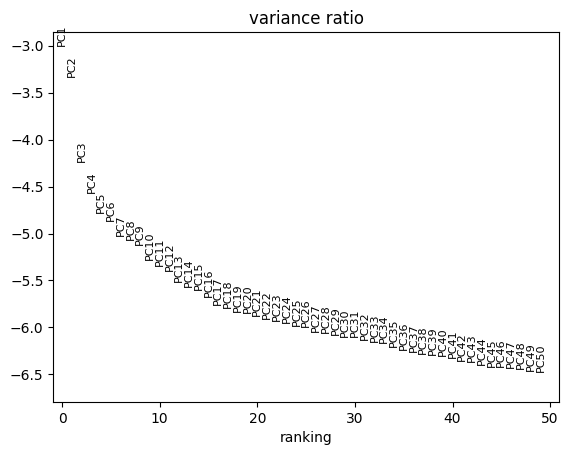

In [5]:
plt.rcdefaults()
sc.tl.pca(ad)
sc.pl.pca_variance_ratio(ad, n_pcs=50, log=True)
sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)

In [ ]:
sc.tl.umap(ad, min_dist=0.1)

In [13]:
resolutions = [0.5, 1, 1.5, 2]

for resolution in resolutions:
    key = f'leiden_{resolution}'
    
    # Check if clustering already exists
    if key in ad.obs.columns:
        print(f"⏭️  Skipping resolution {resolution} (already in ad.obs)")
        continue

    print(f"🔹 Clustering at resolution {resolution}...")
    sc.tl.leiden(ad, resolution=resolution, key_added=key)
    print(f"✅ Done: stored in ad.obs['{key}']")

⏭️  Skipping resolution 0.5 (already in ad.obs)
⏭️  Skipping resolution 1 (already in ad.obs)
🔹 Clustering at resolution 1.5...


IOStream.flush timed out


✅ Done: stored in ad.obs['leiden_1.5']
🔹 Clustering at resolution 2...
✅ Done: stored in ad.obs['leiden_2']


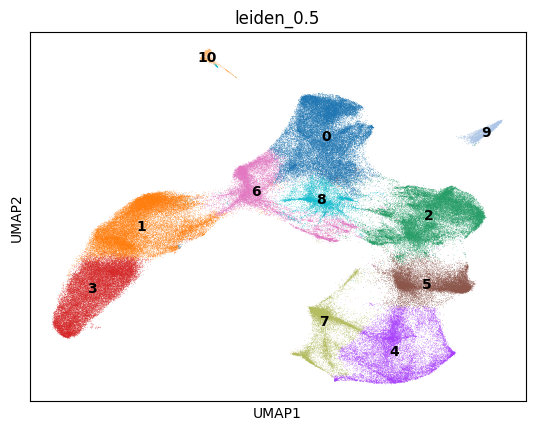

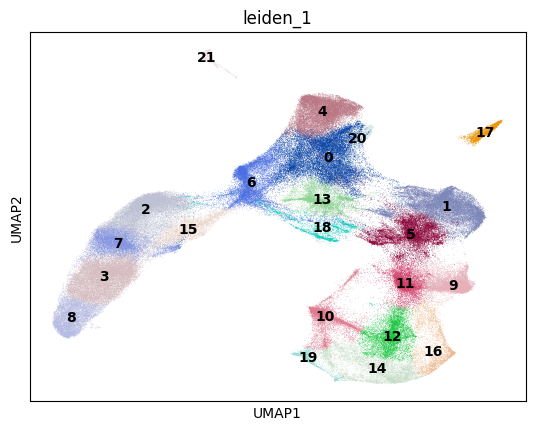

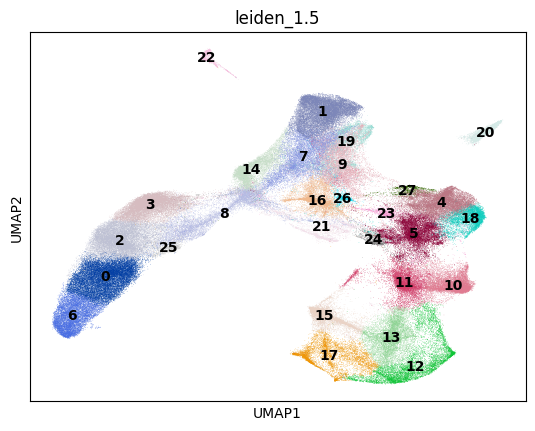

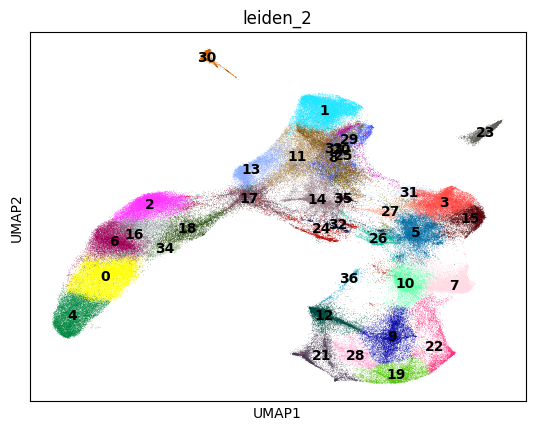

In [14]:
sc.pl.umap(ad, color = 'leiden_0.5', legend_loc = 'on data')
sc.pl.umap(ad, color = 'leiden_1', legend_loc = 'on data')
sc.pl.umap(ad, color = 'leiden_1.5', legend_loc = 'on data')
sc.pl.umap(ad, color = 'leiden_2', legend_loc = 'on data')

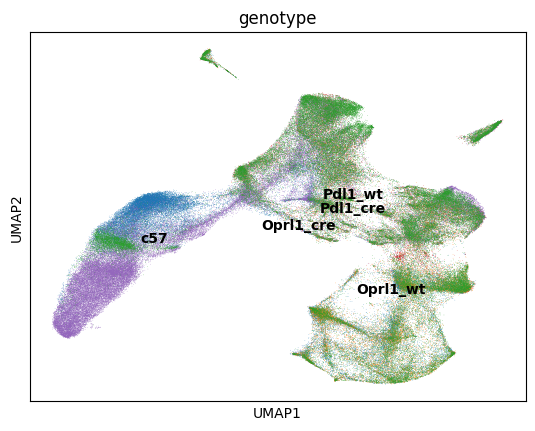

In [9]:
sc.pl.umap(ad, color = 'genotype', legend_loc = 'on data')

Pdl1_wt


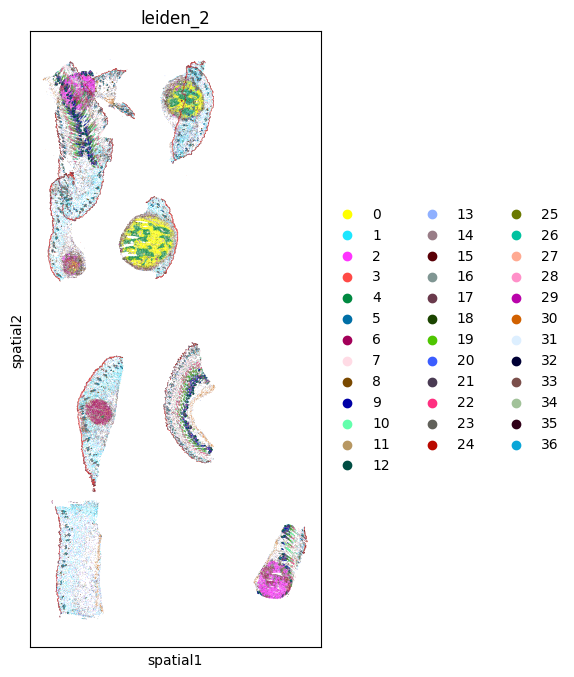

In [15]:
sample_id = []
print(ad.obs.condition.unique()[0])
with plt.rc_context({'figure.figsize': (10, 8)}):
    sc.pl.spatial(ad, spot_size=15, color = 'leiden_2')
plt.show()


Pdl1_wt


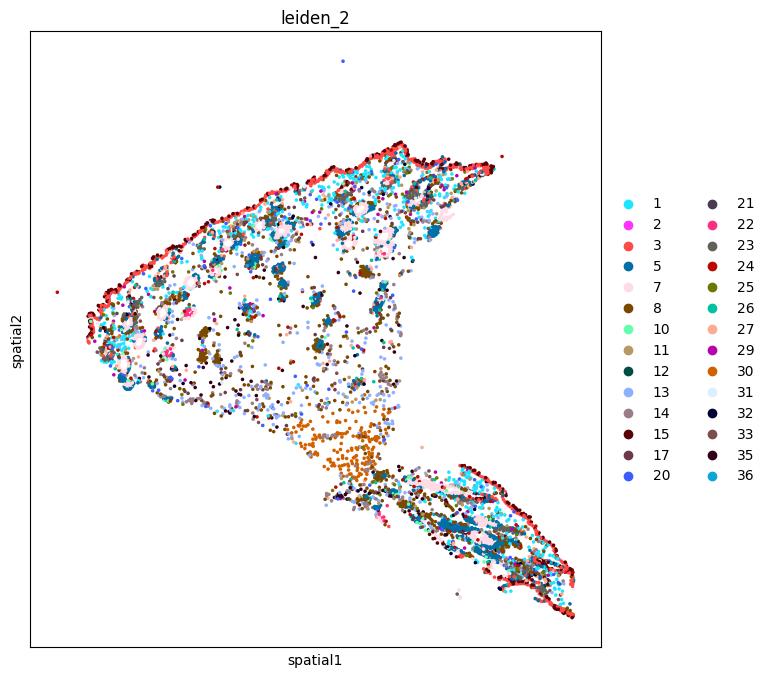

Pdl1_wt


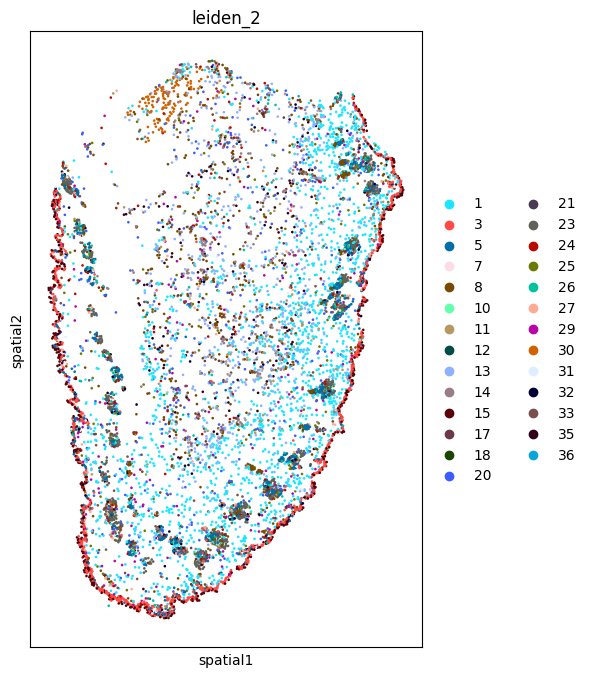

Oprl1_cre


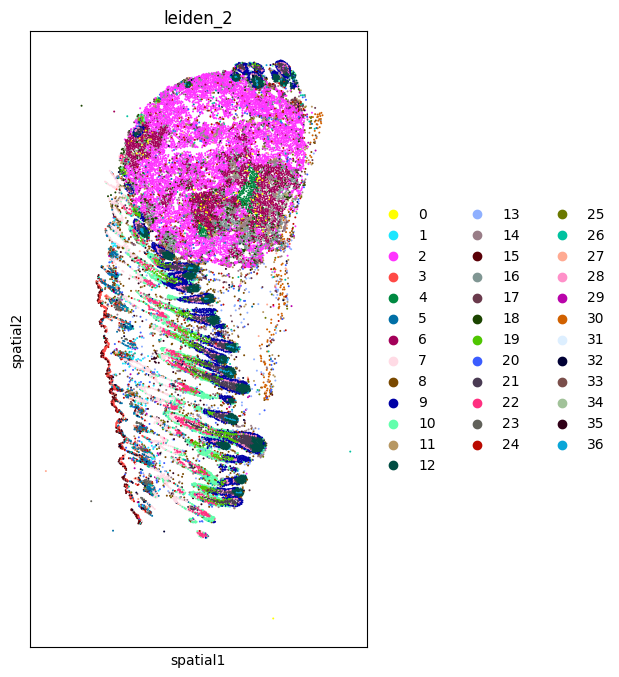

Oprl1_cre


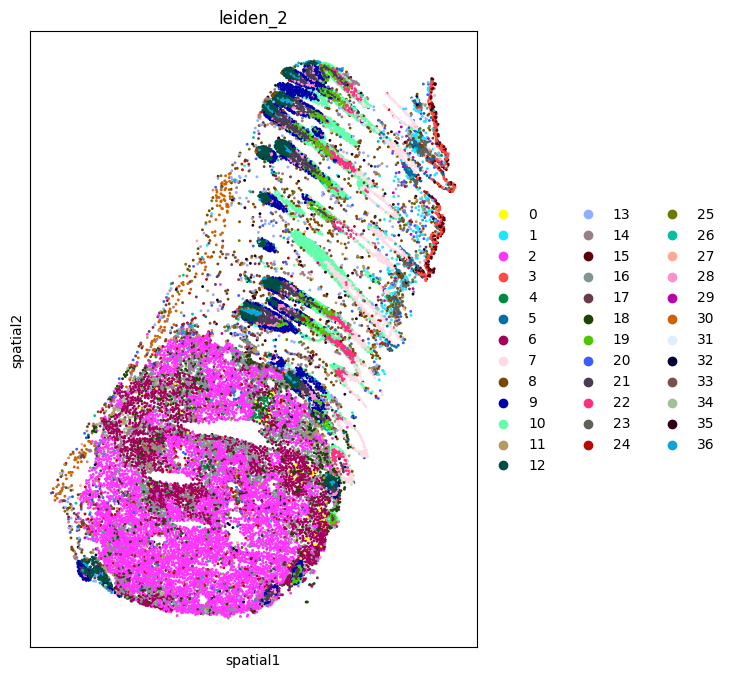

c57


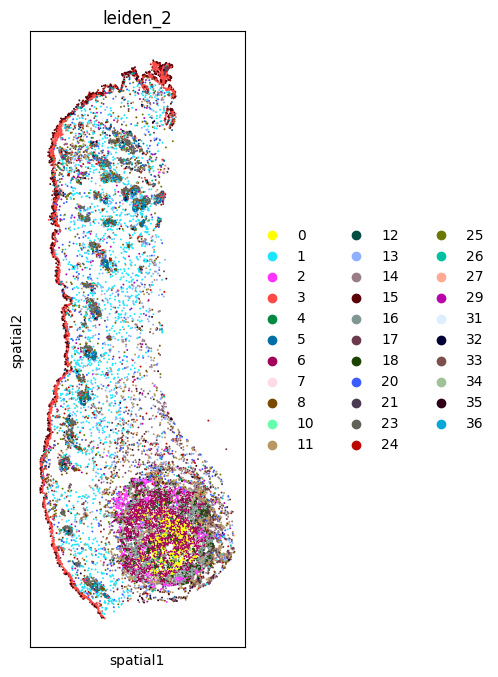

c57


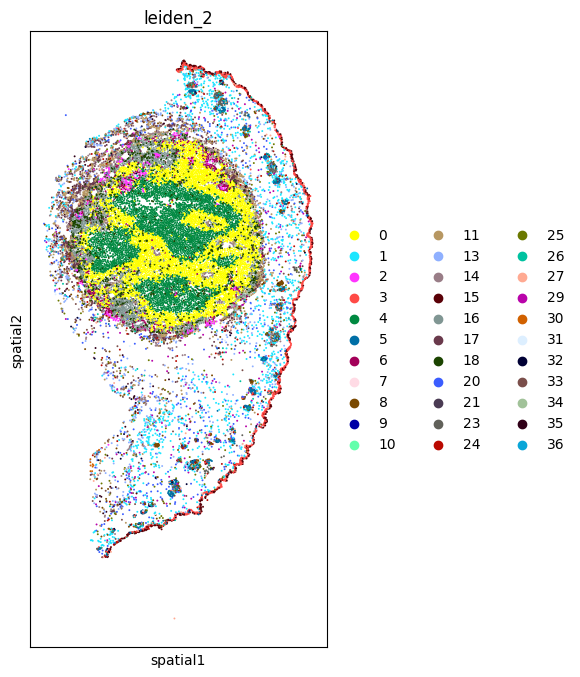

c57


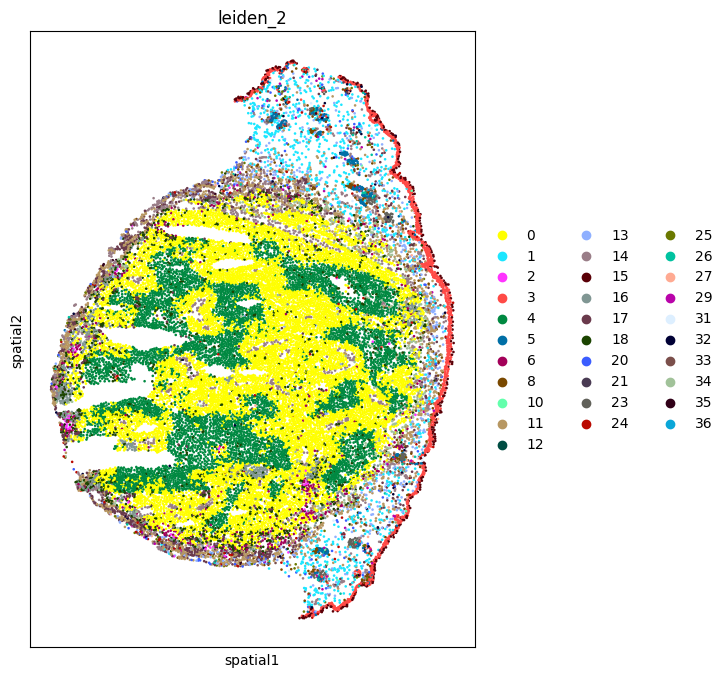

Oprl1_wt


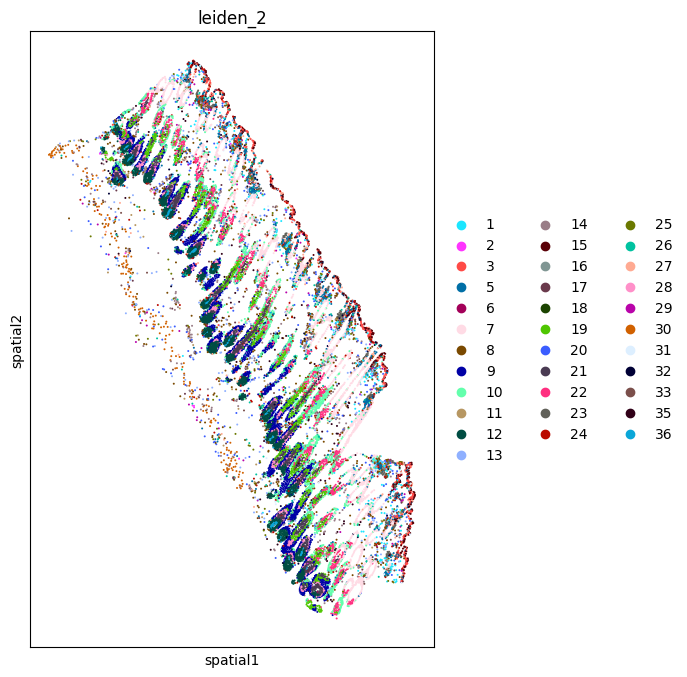

Pdl1_cre


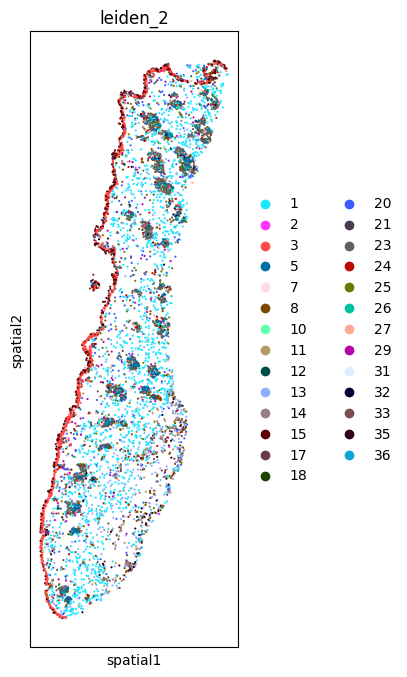

Pdl1_cre


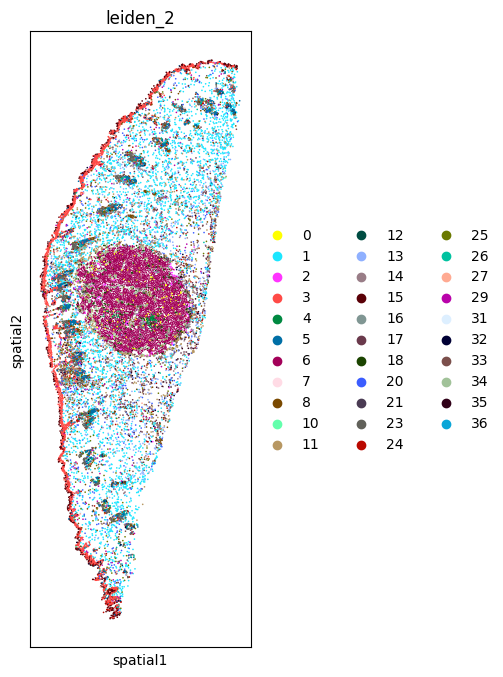

Pdl1_cre


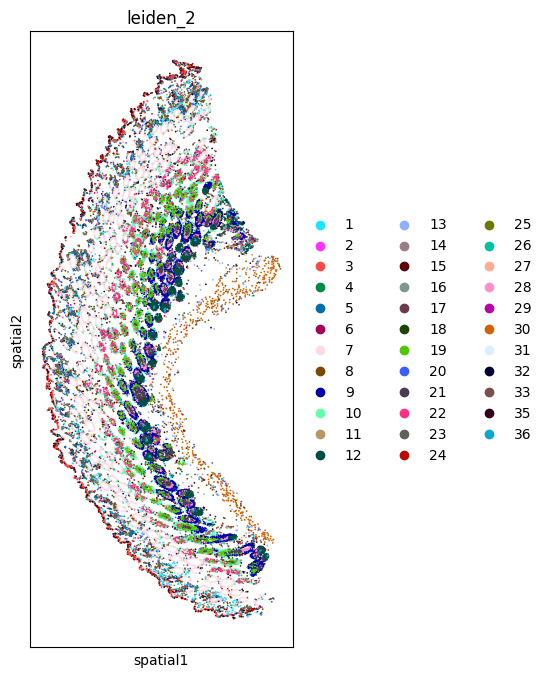

Pdl1_cre


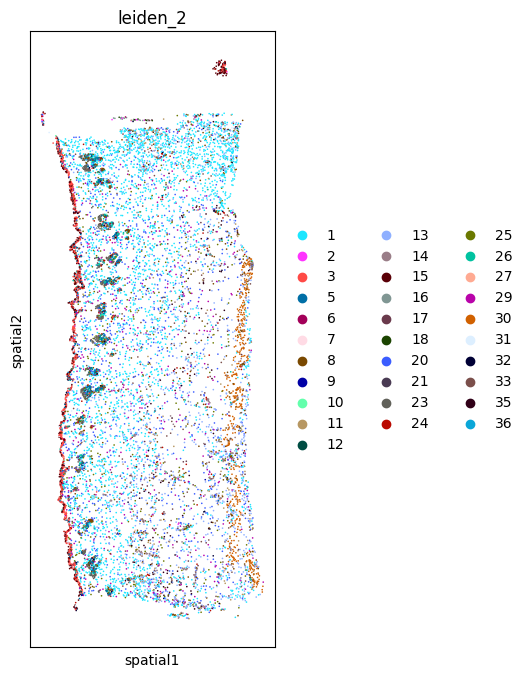

In [16]:
sample_id = []
for grid in ad.obs['sample_id'].unique():    
    ad_int = ad[ad.obs['sample_id'] == grid]
    print(ad_int.obs.condition.unique()[0])
    with plt.rc_context({'figure.figsize': (10, 8)}):
        sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_2')
    plt.show()


In [17]:

# assume you have run clustering already
sc.tl.rank_genes_groups(ad, groupby="leiden_2", method="wilcoxon")

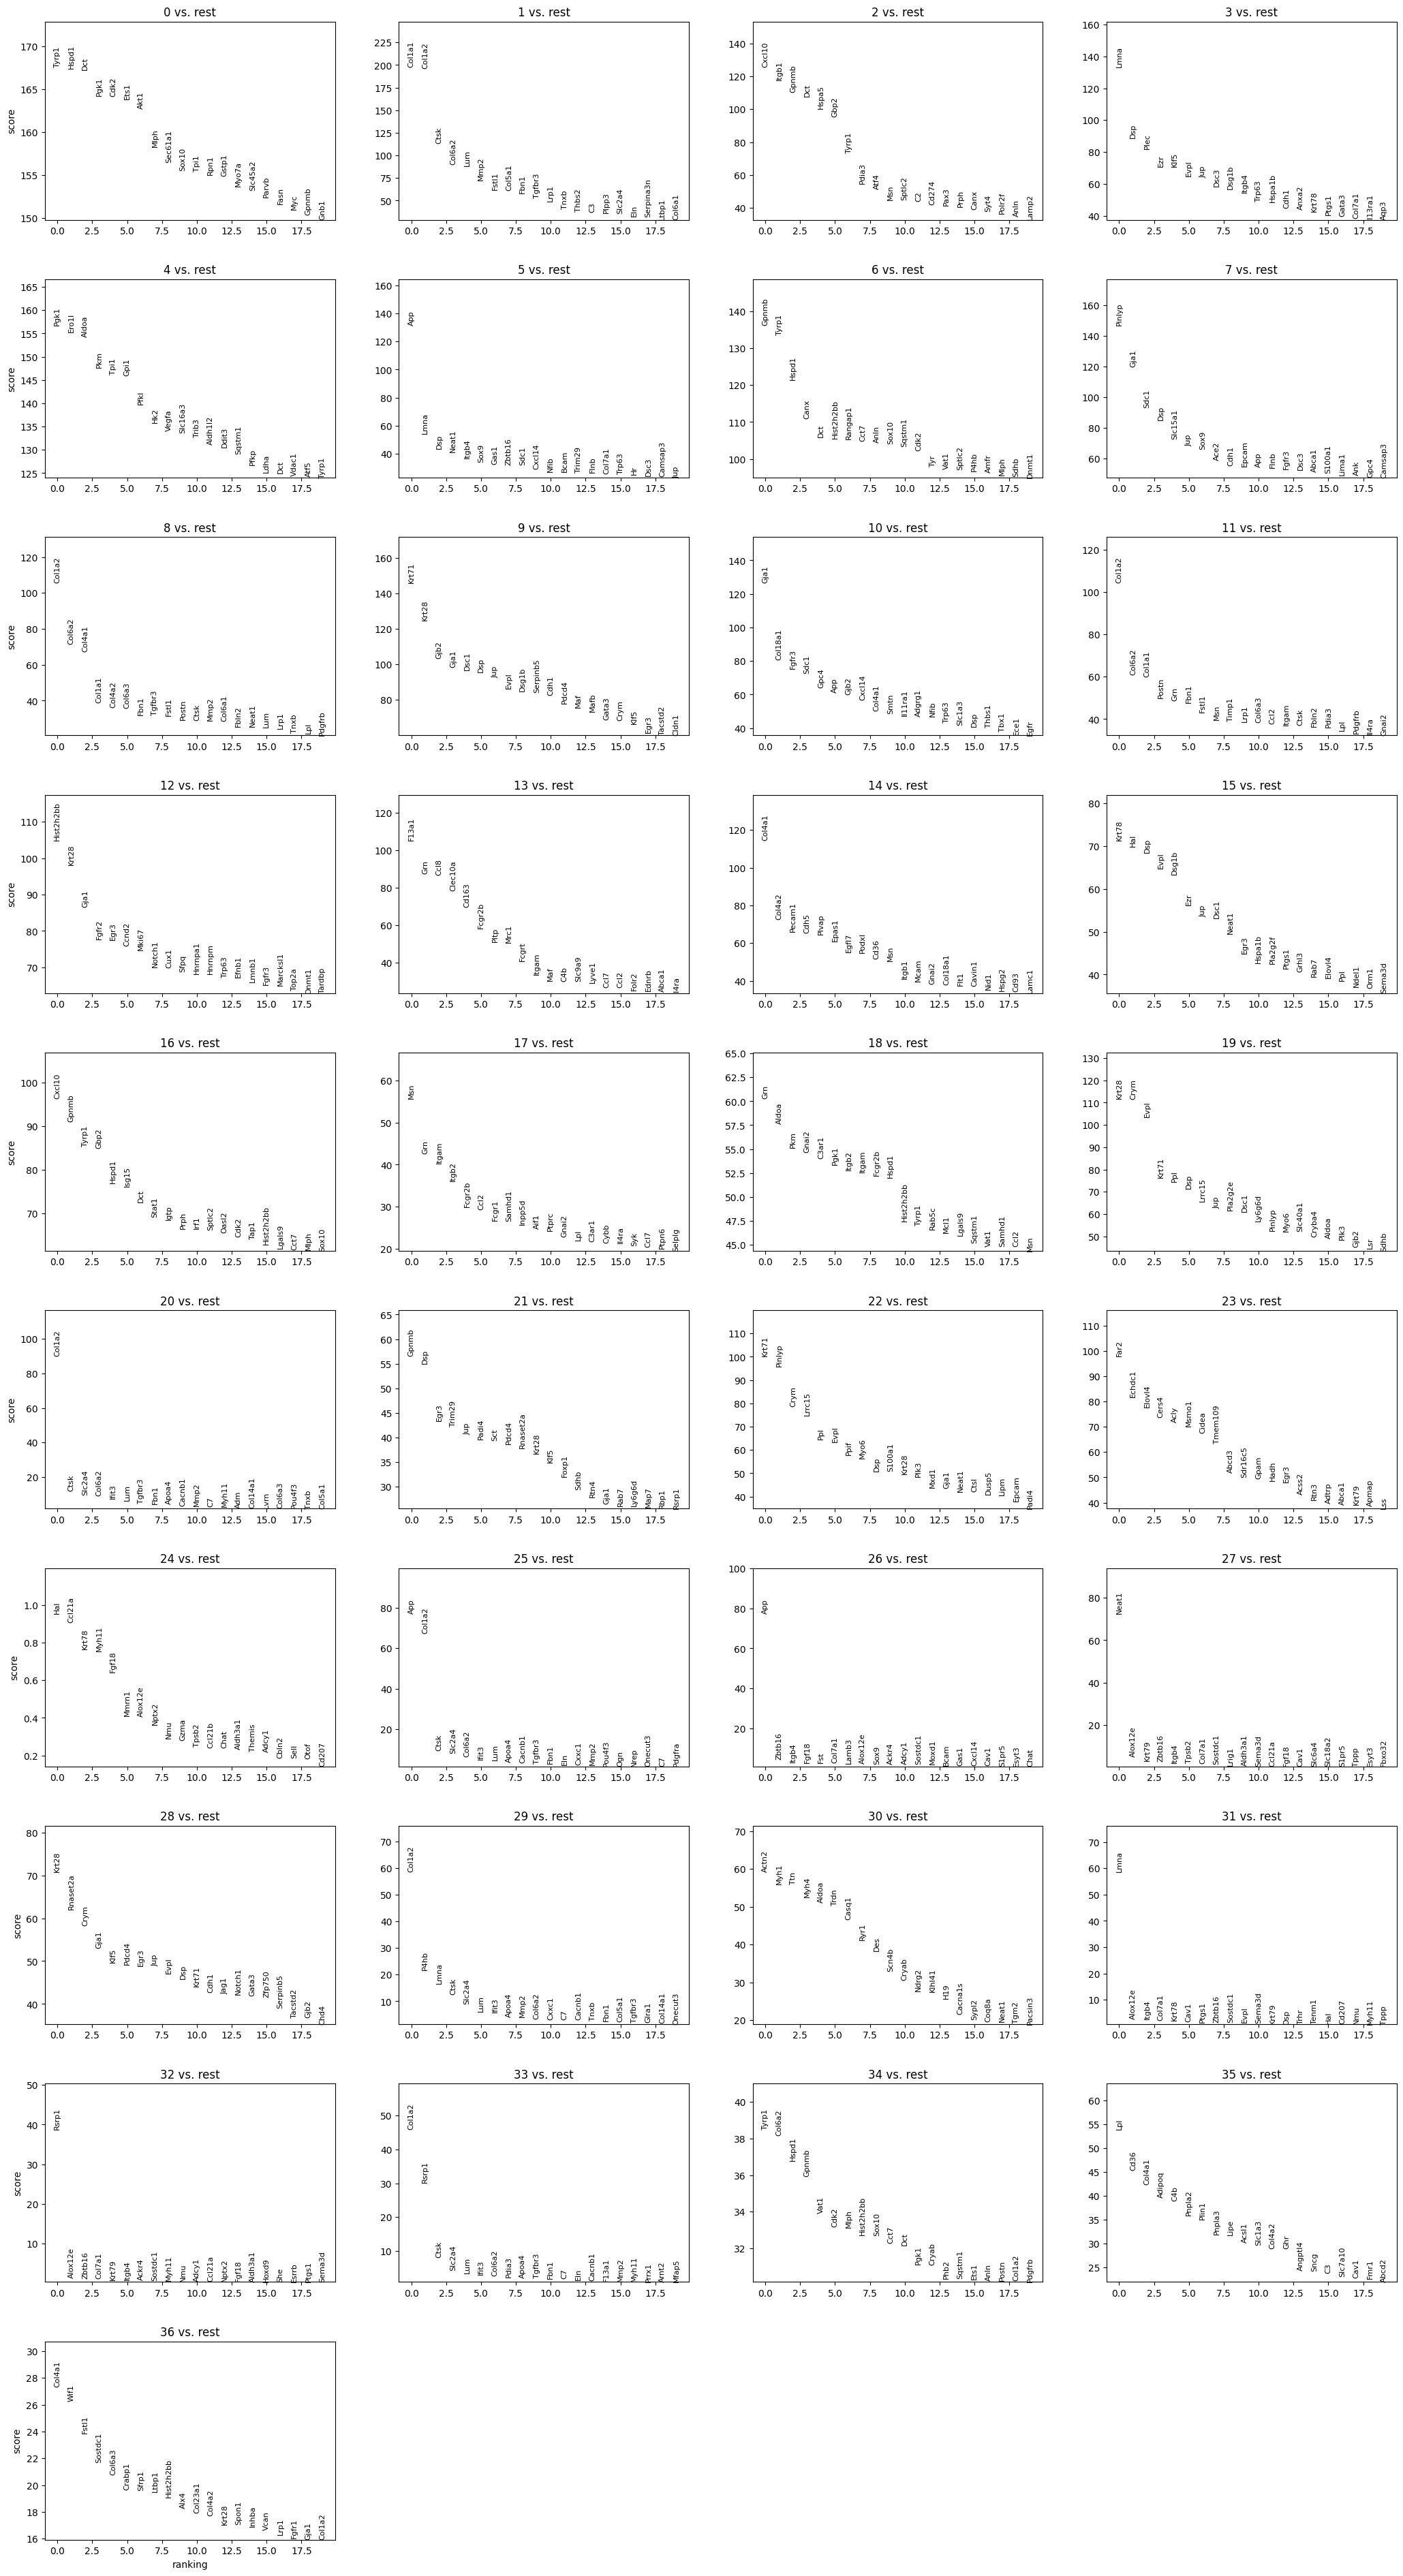

In [18]:
sc.pl.rank_genes_groups(ad, n_genes=20, sharey=False, ncols=4)

In [19]:
marker_genes = pd.DataFrame({
    group: ad.uns['rank_genes_groups']['names'][group][:20]
    for group in ad.uns['rank_genes_groups']['names'].dtype.names
})
marker_genes.head()
#marker_genes.to_csv('../data/broad_markers_leiden0-5.csv')

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,Tyrp1,Col1a1,Cxcl10,Lmna,Pgk1,App,Gpnmb,Pinlyp,Col1a2,Krt71,...,Neat1,Krt28,Col1a2,Actn2,Lmna,Rsrp1,Col1a2,Tyrp1,Lpl,Col4a1
1,Hspd1,Col1a2,Itgb1,Dsp,Ero1l,Lmna,Tyrp1,Gja1,Col6a2,Krt28,...,Alox12e,Rnaset2a,P4hb,Myh1,Alox12e,Alox12e,Rsrp1,Col6a2,Cd36,Wif1
2,Dct,Ctsk,Gpnmb,Plec,Aldoa,Dsp,Hspd1,Sdc1,Col4a1,Gjb2,...,Krt79,Crym,Lmna,Ttn,Itgb4,Zbtb16,Ctsk,Hspd1,Col4a1,Fstl1
3,Pgk1,Col6a2,Dct,Ezr,Pkm,Neat1,Canx,Dsp,Col1a1,Gja1,...,Zbtb16,Gja1,Ctsk,Myh4,Col7a1,Col7a1,Slc2a4,Gpnmb,Adipoq,Sostdc1
4,Cdk2,Lum,Hspa5,Klf5,Tpi1,Itgb4,Dct,Slc15a1,Col4a2,Dsc1,...,Itgb4,Klf5,Slc2a4,Aldoa,Krt78,Krt79,Lum,Vat1,C4b,Col6a3


In [20]:
marker_dict = {}
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')
    marker_dict[col] = genes[:3]

0
Tyrp1 Hspd1 Dct Pgk1 Cdk2 Ets1 Akt1 Mlph Sec61a1 Sox10 Tpi1 Rpn1 Gstp1 Myo7a Slc45a2 Parvb Fasn Myc Gpnmb Gnb1
 
1
Col1a1 Col1a2 Ctsk Col6a2 Lum Mmp2 Fstl1 Col5a1 Fbn1 Tgfbr3 Lrp1 Tnxb Thbs2 C3 Plpp3 Slc2a4 Eln Serpina3n Ltbp1 Col6a1
 
2
Cxcl10 Itgb1 Gpnmb Dct Hspa5 Gbp2 Tyrp1 Pdia3 Atf4 Msn Sptlc2 C2 Cd274 Pax3 Prph Canx Syt4 Polr2f Anln Lamp2
 
3
Lmna Dsp Plec Ezr Klf5 Evpl Jup Dsc3 Dsg1b Itgb4 Trp63 Hspa1b Cdh1 Anxa2 Krt78 Ptgs1 Gata3 Col7a1 Il13ra1 Aqp3
 
4
Pgk1 Ero1l Aldoa Pkm Tpi1 Gpi1 Pfkl Hk2 Vegfa Slc16a3 Trib3 Aldh1l2 Ddit3 Sqstm1 Pfkp Ldha Dct Vdac1 Atf5 Tyrp1
 
5
App Lmna Dsp Neat1 Itgb4 Sox9 Gas1 Zbtb16 Sdc1 Cxcl14 Nfib Bcam Trim29 Flnb Col7a1 Trp63 Hr Dsc3 Camsap3 Jup
 
6
Gpnmb Tyrp1 Hspd1 Canx Dct Hist2h2bb Rangap1 Cct7 Anln Sox10 Sqstm1 Cdk2 Tyr Vat1 Sptlc2 P4hb Amfr Mlph Sdhb Dnmt1
 
7
Pinlyp Gja1 Sdc1 Dsp Slc15a1 Jup Sox9 Ace2 Cdh1 Epcam App Flnb Fgfr3 Dsc3 Abca1 S100a1 Lima1 Ank Gpc4 Camsap3
 
8
Col1a2 Col6a2 Col4a1 Col1a1 Col4a2 Col6a3 Fbn1 Tgfbr3 Fstl1 Postn Ctsk

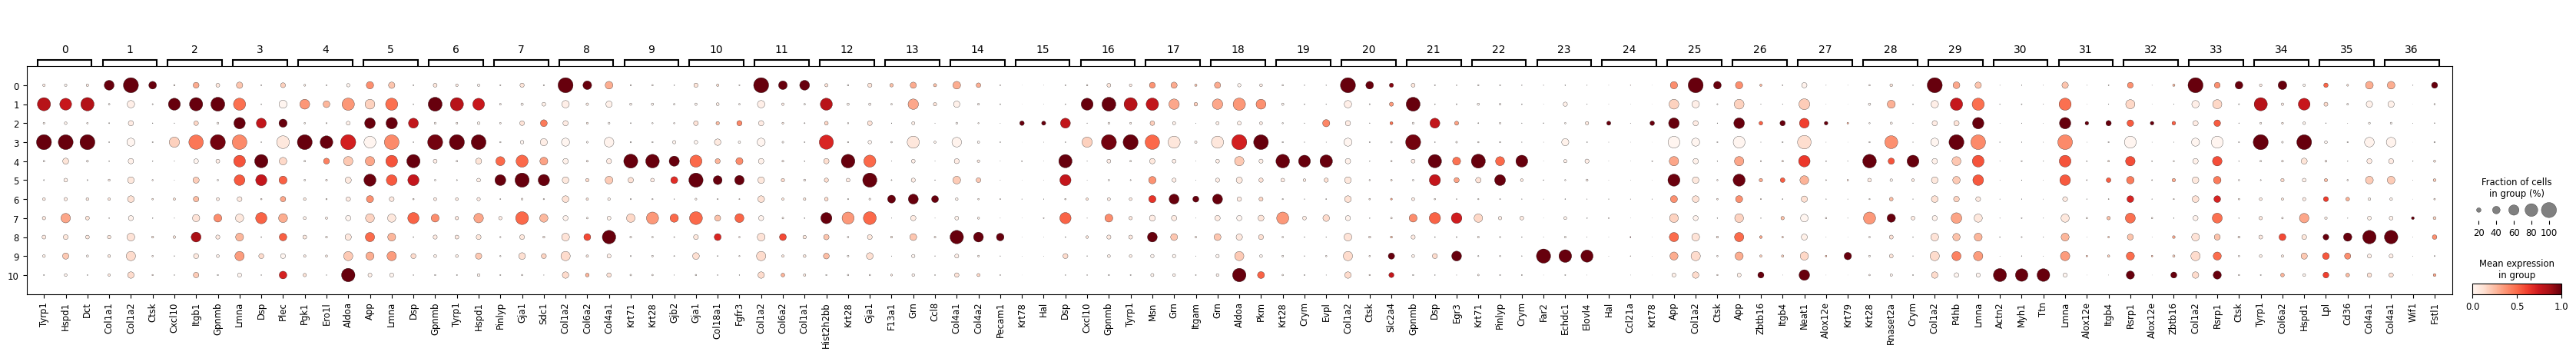

In [21]:
sc.pl.dotplot(ad, marker_dict, groupby="leiden_0.5", standard_scale="var")

In [22]:
ad.write('../../data/talbot_xenium_tumor.h5ad')